# Embedding interpolation

Same idea as the flip notebook, but with no correct answer to break.

Take a phrase like "I like pizza, and I always order extra ___". Pick one word (here, "pizza") and slowly blend its embedding toward a target word ("salad"). Sweep a mixing weight `alpha` from 0 (pure "pizza") to 1 (pure "salad") and watch what the model predicts next at each step.

There's no right token. At alpha=0 the model predicts whatever it predicts for pizza; at alpha=1, whatever it predicts for salad. The interesting part is the middle: what does the favorite topping become halfway between pizza and salad?

## Method

For each `alpha` in `[0, 1]`:

1. Blend the embedding at the chosen index: `(1 - alpha) * original + alpha * target`
2. Run the forward pass with the modified embeddings
3. Softmax the final-position logits and record the top-5 tokens

The blend is in embedding space, not probability space. Whatever the rest of the network does with that blended vector is the output.

The two charts show the top-5 probabilities across the sweep. The line chart reads individual token values; the stacked area chart shows probability mass handing off from one token to the next (only tokens that passed a certain threshold probability are displayed to prevent visual clutter). Dashed lines mark each transition.

### **Imports**

In [20]:
from transformers import AutoModelForCausalLM, AutoTokenizer, logging
import torch
import time

In [21]:
logging.set_verbosity_error()
logging.disable_progress_bar()

### **Set variables**

In [38]:
model_name = "gpt2"

query = ("I love school because it's very", 1, "hate") # (phrase, index to morph, target word) 

In [39]:
gen_time = 0

_CACHE = {}

# tokenizer = AutoTokenizer.from_pretrained(model_name)
# model = AutoModelForCausalLM.from_pretrained(model_name, output_hidden_states=True)

model_name="gpt2"
if model_name not in _CACHE:
    tok = AutoTokenizer.from_pretrained(model_name)
    mdl = AutoModelForCausalLM.from_pretrained(model_name)
    _CACHE[model_name] = (tok, mdl)

(tokenizer, model) = _CACHE[model_name]


embedding_layer = model.get_input_embeddings()


""" returns the embedding vector of a word W """
def get_word_embedding(W: str, leading_space=True) -> torch.Tensor:
    text = (" " + W) if leading_space else W
    ids = tokenizer.encode(text)
    if len(ids) != 1:
        toks = tokenizer.convert_ids_to_tokens(ids)
        print(f"  warning: {W!r} -> {len(ids)} tokens {toks}, using first")
    return embedding_layer.weight[ids[0]]

In [24]:
(phrase, changed_index, target_word) = query

### Now we gradually change the embeddings of the word "love" in the phrase to the embedding of "hate," and we can see when our most probably next word shifts 

In [40]:
start_time = time.perf_counter()

inputs = tokenizer(phrase, return_tensors="pt")
attn = inputs["attention_mask"]
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print("tokens:", list(enumerate(tokens)))

base_embeds = embedding_layer(inputs["input_ids"]).detach()
original_vec = base_embeds[0, changed_index, :].clone()
target_vec = get_word_embedding(target_word)
morph_word = tokenizer.decode(inputs["input_ids"][0][changed_index]).strip()

top_5_at_each_alpha = {}
transitions = []          # (alpha, from_token, to_token) each time the top token changes
prev_top = None

for i, alpha in enumerate(torch.linspace(0, 1, 101)):
    embeds = base_embeds.clone()
    embeds[0, changed_index, :] = (1 - alpha) * original_vec + alpha * target_vec

    with torch.no_grad():
        logits = model(inputs_embeds=embeds, attention_mask=attn).logits

    last_token_probs = torch.softmax(logits[0, -1, :], dim=-1)
    top5 = torch.topk(last_token_probs, 5)
    top_5_at_each_alpha[i] = top5

    pred = tokenizer.decode(top5.indices[0]).strip()
    if prev_top is not None and pred != prev_top:
        transitions.append((alpha.item(), prev_top, pred))
    prev_top = pred

gen_time += time.perf_counter() - start_time

start_top = tokenizer.decode(top_5_at_each_alpha[0].indices[0]).strip()
end_top = tokenizer.decode(top_5_at_each_alpha[100].indices[0]).strip()

print(f"\nmorphing {morph_word!r} -> {target_word!r}")
print(f"  alpha=0.00   {start_top!r}")
for a, frm, to in transitions:
    print(f"  alpha={a:.2f}   {frm!r} -> {to!r}")
print(f"  alpha=1.00   {end_top!r}")
print(f"  {len(transitions)} change(s) across the sweep")

tokens: [(0, 'I'), (1, 'Ġlove'), (2, 'Ġschool'), (3, 'Ġbecause'), (4, 'Ġit'), (5, "'s"), (6, 'Ġvery')]

morphing 'love' -> 'hate'
  alpha=0.00   'fun'
  alpha=0.59   'fun' -> ','
  alpha=0.62   ',' -> 'hard'
  alpha=1.00   'hard'
  2 change(s) across the sweep


In [26]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


### **Plotting results of changing "I love school because it's very..." to "I hate school because it's very...":**

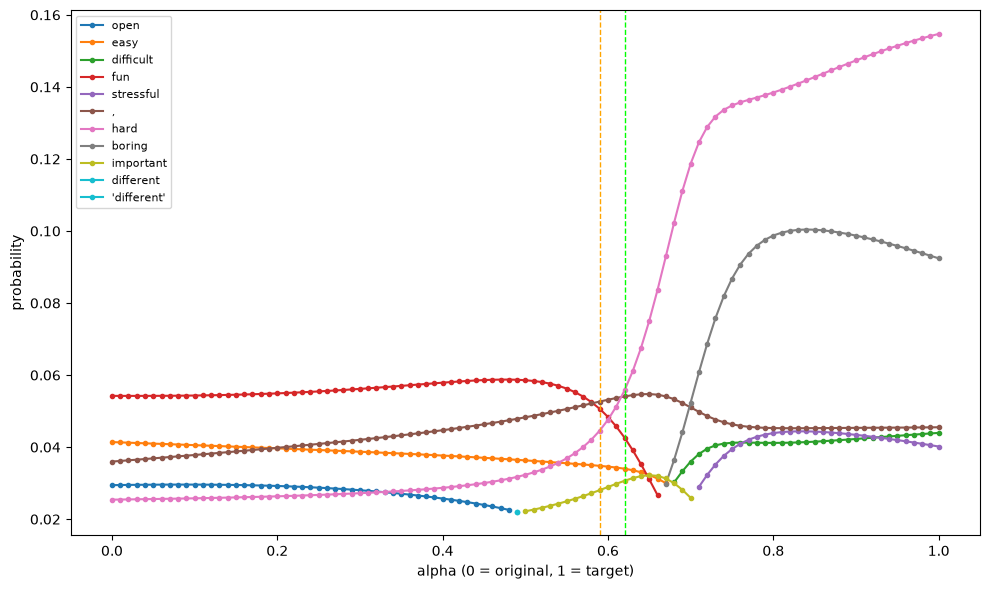

In [47]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe

steps = sorted(top_5_at_each_alpha)
per_step = {i: {idx.item(): p.item()
               for p, idx in zip(top_5_at_each_alpha[i].values,
                                 top_5_at_each_alpha[i].indices)}
            for i in steps}
all_ids = {t for d in per_step.values() for t in d}


cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fallback = iter(cycle)

fig, ax = plt.subplots(figsize=(10, 6))


for tok_id in all_ids:
    word = tokenizer.decode(tok_id).strip().lower()
    color = word if word in mcolors.CSS4_COLORS else next(fallback)
    if word == "black":
        color = "dimgray"
    alphas = [i / 100 for i in steps]
    probs  = [per_step[i].get(tok_id, float("nan")) for i in steps]
    # print(repr(tokenizer.decode(tok_id)))
    ax.plot(alphas, probs, marker=".", color=color, label=tokenizer.decode(tok_id).strip())



effects = [pe.Stroke(linewidth=3, foreground="white"), pe.Normal()] if word == "black" else None
ax.plot(alphas, probs, color=color, marker=".", label=repr(word), path_effects=effects)

ax.set_xlabel("alpha (0 = original, 1 = target)")
ax.set_ylabel("probability")
ax.legend(fontsize=8)

plt.style.use('dark_background')

ax.axvline(0.59, color="orange", linestyle="--", linewidth=1)
ax.axvline(0.62, color="lime", linestyle="--", linewidth=1)
plt.style.use("default")
plt.tight_layout()
plt.show()

### **Also in a stacked area chart**

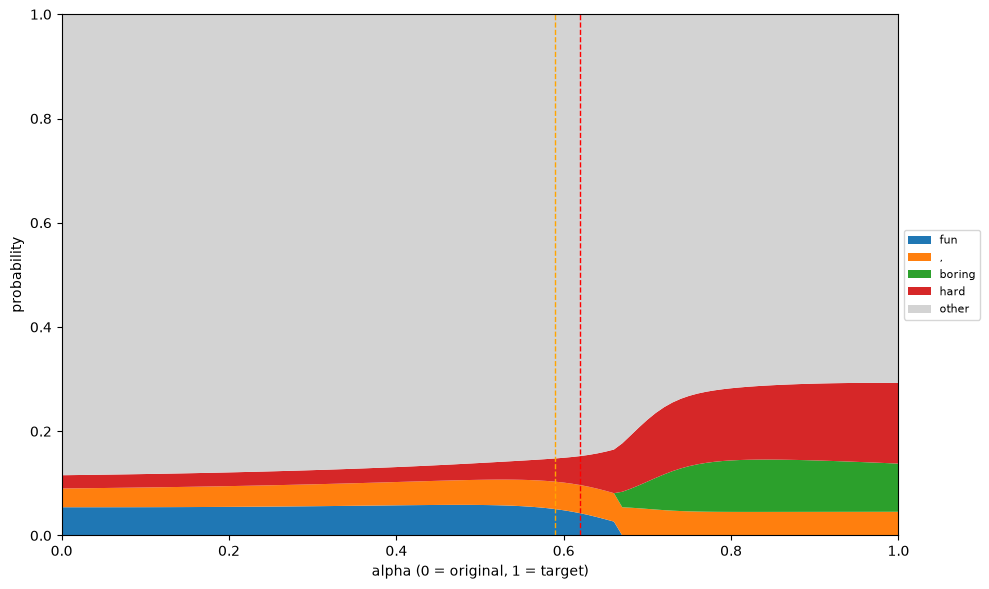

In [43]:
import numpy as np

alphas = np.array([i / 100 for i in steps])
band = {t: np.array([per_step[i].get(t, 0.0) for i in steps]) for t in all_ids}

THRESH = 0.05 # tokens with <10% prob throughout all alpha go into "other"
keep = [t for t in all_ids if band[t].max() >= THRESH]
keep = sorted(keep, key=lambda t: int(np.argmax(band[t])))
words = [tokenizer.decode(t).strip().lower() for t in keep]

fallback = iter(plt.get_cmap("tab10").colors)
def color_for(w):
    if w in mcolors.CSS4_COLORS:
        return "dimgray" if w == "black" else w
    return next(fallback)
colors = [color_for(w) for w in words]

M = np.vstack([band[t] for t in keep])
other = 1 - M.sum(axis=0)   # everything below threshold, plus tail outside top-5

fig, ax = plt.subplots(figsize=(10, 6))
ax.stackplot(alphas, *M, other,
             labels=words + ["other"],
             colors=colors + ["lightgray"],
             baseline="zero")

ax.set_xlabel("alpha (0 = original, 1 = target)")
ax.set_ylabel("probability")
ax.set_xlim(alphas[0], alphas[-1]); ax.set_ylim(0, 1)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)

ax.axvline(0.59, color="orange", linestyle="--", linewidth=1)
ax.axvline(0.62, color="red", linestyle="--", linewidth=1)

plt.tight_layout(); plt.show()

## Now, with put everything into one function:

In [58]:
from itertools import cycle

_MODEL_CACHE = {}

def _load(model_name):
    if model_name not in _MODEL_CACHE:
        tok = AutoTokenizer.from_pretrained(model_name)
        mdl = AutoModelForCausalLM.from_pretrained(model_name)
        _MODEL_CACHE[model_name] = (tok, mdl)
    return _MODEL_CACHE[model_name]


def drift_sentence_meaning(model_name, phrase, target_word, changed_index, n_steps=101, thresh=0.10):
    tokenizer, model = _load(model_name)
    embedding_layer = model.get_input_embeddings()

    def word_embedding(w):
        ids = tokenizer.encode(" " + w)
        if len(ids) != 1:
            print(f"warning: {w!r} -> {len(ids)} tokens, using first")
        return embedding_layer.weight[ids[0]]

    inputs = tokenizer(phrase, return_tensors="pt")
    attn = inputs["attention_mask"]
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    print("tokens:", list(enumerate(tokens)))

    base_embeds = embedding_layer(inputs["input_ids"]).detach()
    original_vec = base_embeds[0, changed_index, :].clone()
    target_vec = word_embedding(target_word)
    morph_word = tokenizer.decode([int(inputs["input_ids"][0][changed_index])]).strip()

    top5_by_step, transitions, prev_top = {}, [], None
    for i, alpha in enumerate(torch.linspace(0, 1, n_steps)):
        embeds = base_embeds.clone()
        embeds[0, changed_index, :] = (1 - alpha) * original_vec + alpha * target_vec
        with torch.no_grad():
            logits = model(inputs_embeds=embeds, attention_mask=attn).logits
        probs = torch.softmax(logits[0, -1, :], dim=-1)
        top5 = torch.topk(probs, 5)
        top5_by_step[i] = top5
        pred = tokenizer.decode(top5.indices[0]).strip()
        if prev_top is not None and pred != prev_top:
            transitions.append((i / (n_steps - 1), prev_top, pred))
        prev_top = pred

    start_top = tokenizer.decode(top5_by_step[0].indices[0]).strip()
    end_top = tokenizer.decode(top5_by_step[n_steps - 1].indices[0]).strip()
    print(f"\nmorphing {morph_word!r} -> {target_word!r}")
    print(f"  alpha=0.00   {start_top!r}")
    for a, frm, to in transitions:
        print(f"  alpha={a:.2f}   {frm!r} -> {to!r}")
    print(f"  alpha=1.00   {end_top!r}")
    print(f"  {len(transitions)} change(s) across the sweep")

    steps = sorted(top5_by_step)
    alphas = np.array([i / (n_steps - 1) for i in steps])
    per_step = {i: {idx.item(): p.item()
                    for p, idx in zip(top5_by_step[i].values, top5_by_step[i].indices)}
                for i in steps}
    all_ids = {t for d in per_step.values() for t in d}

    fallback = cycle(plt.get_cmap("tab10").colors)
    color_by_id = {}
    for t in sorted(all_ids):
        w = tokenizer.decode(t).strip().lower()
        color_by_id[t] = ("dimgray" if w == "black"
                        else w if w in mcolors.CSS4_COLORS else next(fallback))

    fig, ax = plt.subplots(figsize=(10, 6))
    for t in all_ids:
        probs = [per_step[i].get(t, float("nan")) for i in steps]
        ax.plot(alphas, probs, marker=".", color=color_by_id[t],
                label=tokenizer.decode(t).strip())
    for a, *_ in transitions:
        ax.axvline(a, color="red", linestyle="--", linewidth=1)
    ax.set_xlabel("alpha (0 = original, 1 = target)")
    ax.set_ylabel("probability")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    band = {t: np.array([per_step[i].get(t, 0.0) for i in steps]) for t in all_ids}
    keep = sorted((t for t in all_ids if band[t].max() >= thresh),
                  key=lambda t: int(np.argmax(band[t])))
    if not keep:
        keep = sorted(all_ids, key=lambda t: -band[t].max())[:5]
        keep = sorted(keep, key=lambda t: int(np.argmax(band[t])))
    M = np.vstack([band[t] for t in keep])
    other = 1 - M.sum(axis=0)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.stackplot(alphas, *M, other,
                 labels=[tokenizer.decode(t).strip().lower() for t in keep] + ["other"],
                 colors=[color_by_id[t] for t in keep] + ["lightgray"])
    for a, *_ in transitions:
        ax.axvline(a, color="red", linestyle="--", linewidth=1)
    ax.set_xlabel("alpha (0 = original, 1 = target)")
    ax.set_ylabel("probability")
    ax.set_xlim(alphas[0], alphas[-1]); ax.set_ylim(0, 1)
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
    plt.tight_layout(); plt.show()

    return top5_by_step, transitions

tokens: [(0, 'I'), (1, 'Ġlike'), (2, 'Ġpizza'), (3, ','), (4, 'Ġand'), (5, 'ĠI'), (6, 'Ġalways'), (7, 'Ġget'), (8, 'Ġit'), (9, 'Ġwith'), (10, 'Ġa'), (11, 'Ġlot'), (12, 'Ġof')]

morphing 'pizza' -> 'salad'
  alpha=0.00   'people'
  alpha=0.06   'people' -> 'different'
  alpha=0.33   'different' -> 'cheese'
  alpha=0.43   'cheese' -> 'vegetables'
  alpha=1.00   'vegetables'
  3 change(s) across the sweep


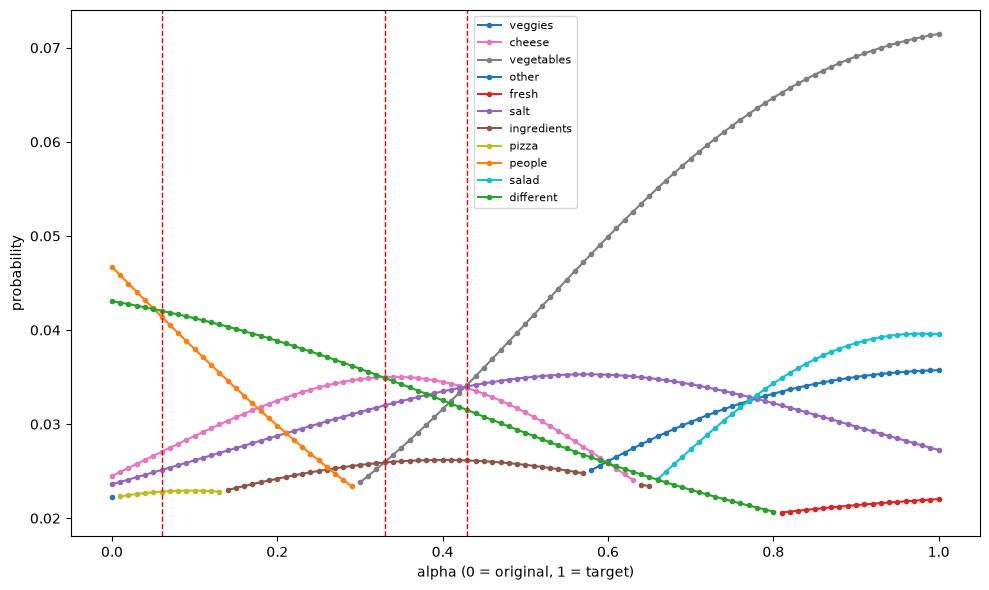

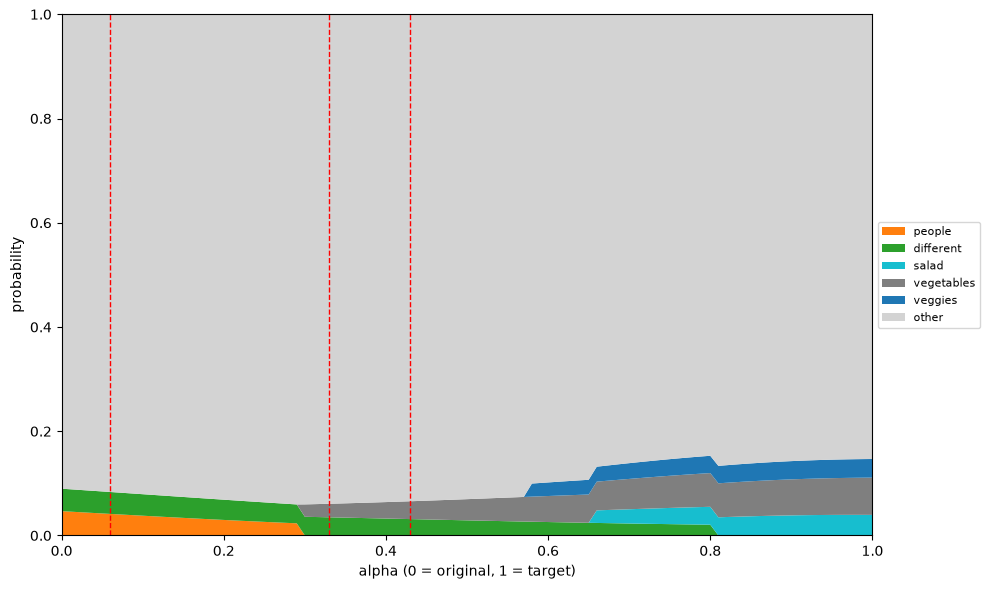

({0: torch.return_types.topk(
  values=tensor([0.0467, 0.0431, 0.0245, 0.0236, 0.0223]),
  indices=tensor([ 661, 1180, 9891, 8268,  584])),
  1: torch.return_types.topk(
  values=tensor([0.0458, 0.0429, 0.0249, 0.0239, 0.0223]),
  indices=tensor([  661,  1180,  9891,  8268, 14256])),
  2: torch.return_types.topk(
  values=tensor([0.0449, 0.0428, 0.0253, 0.0241, 0.0225]),
  indices=tensor([  661,  1180,  9891,  8268, 14256])),
  3: torch.return_types.topk(
  values=tensor([0.0441, 0.0426, 0.0258, 0.0244, 0.0226]),
  indices=tensor([  661,  1180,  9891,  8268, 14256])),
  4: torch.return_types.topk(
  values=tensor([0.0432, 0.0424, 0.0262, 0.0246, 0.0227]),
  indices=tensor([  661,  1180,  9891,  8268, 14256])),
  5: torch.return_types.topk(
  values=tensor([0.0423, 0.0422, 0.0266, 0.0249, 0.0228]),
  indices=tensor([  661,  1180,  9891,  8268, 14256])),
  6: torch.return_types.topk(
  values=tensor([0.0420, 0.0414, 0.0271, 0.0251, 0.0228]),
  indices=tensor([ 1180,   661,  9891,  8268, 

In [59]:
plt.style.use("default")
drift_sentence_meaning("gpt2", "I like pizza, and I always get it with a lot of", "salad", changed_index=2)

tokens: [(0, 'What'), (1, 'Ġhappens'), (2, 'Ġwhen'), (3, 'ĠI'), (4, 'Ġam'), (5, 'Ġin'), (6, 'Ġa')]

morphing 'What' -> 'Pizza'
  alpha=0.00   'position'
  alpha=0.55   'position' -> 'relationship'
  alpha=0.60   'relationship' -> 'place'
  alpha=0.72   'place' -> 'room'
  alpha=0.87   'room' -> 'hurry'
  alpha=1.00   'hurry'
  4 change(s) across the sweep


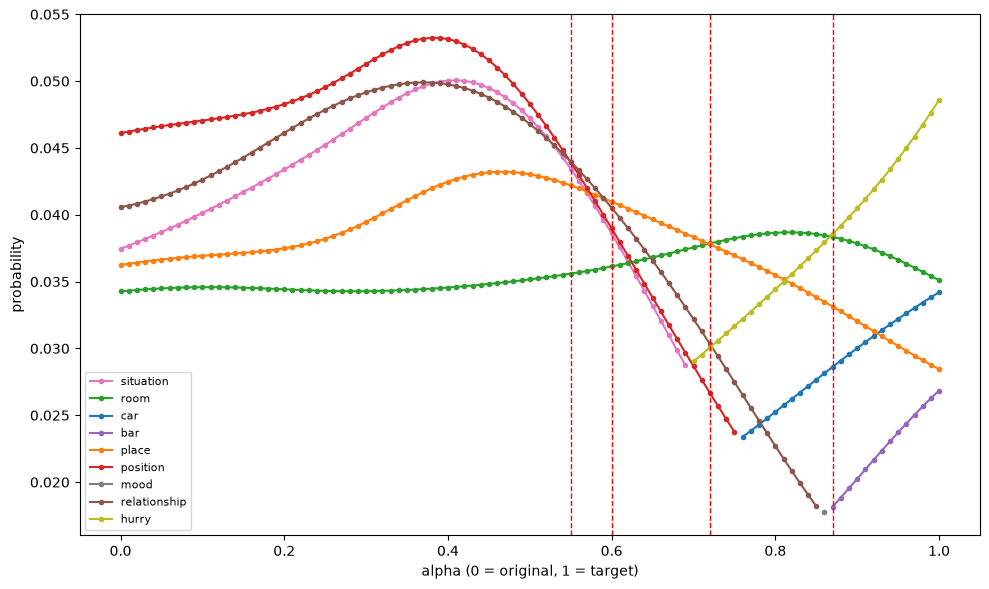

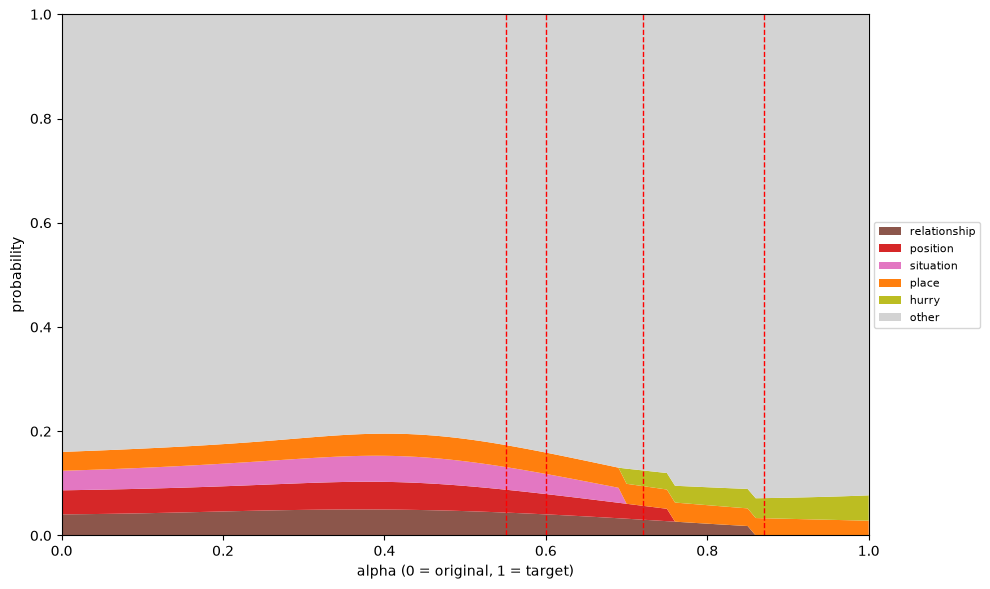

({0: torch.return_types.topk(
  values=tensor([0.0461, 0.0406, 0.0375, 0.0362, 0.0343]),
  indices=tensor([2292, 2776, 3074, 1295, 2119])),
  1: torch.return_types.topk(
  values=tensor([0.0462, 0.0407, 0.0377, 0.0363, 0.0343]),
  indices=tensor([2292, 2776, 3074, 1295, 2119])),
  2: torch.return_types.topk(
  values=tensor([0.0463, 0.0408, 0.0379, 0.0364, 0.0344]),
  indices=tensor([2292, 2776, 3074, 1295, 2119])),
  3: torch.return_types.topk(
  values=tensor([0.0464, 0.0410, 0.0382, 0.0365, 0.0344]),
  indices=tensor([2292, 2776, 3074, 1295, 2119])),
  4: torch.return_types.topk(
  values=tensor([0.0465, 0.0412, 0.0384, 0.0366, 0.0345]),
  indices=tensor([2292, 2776, 3074, 1295, 2119])),
  5: torch.return_types.topk(
  values=tensor([0.0466, 0.0414, 0.0387, 0.0366, 0.0345]),
  indices=tensor([2292, 2776, 3074, 1295, 2119])),
  6: torch.return_types.topk(
  values=tensor([0.0467, 0.0416, 0.0390, 0.0367, 0.0345]),
  indices=tensor([2292, 2776, 3074, 1295, 2119])),
  7: torch.return_ty

In [66]:
drift_sentence_meaning("gpt2", "What happens when I am in a", "Pizza", changed_index=0)

tokens: [(0, 'Let'), (1, "'s"), (2, 'Ġeat'), (3, ','), (4, 'Ġgrandma'), (5, 'Ġbecause'), (6, 'ĠI'), (7, "'m"), (8, 'Ġnot'), (9, 'Ġgoing'), (10, 'Ġto'), (11, 'Ġeat')]

morphing ',' -> ''
  alpha=0.00   'you'
  alpha=0.56   'you' -> 'it'
  alpha=1.00   'it'
  1 change(s) across the sweep


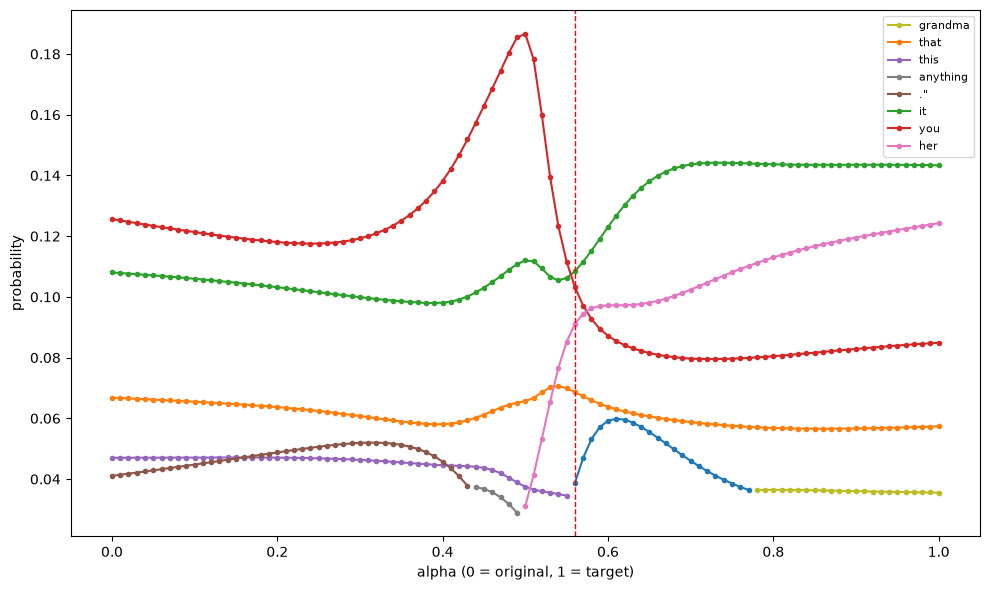

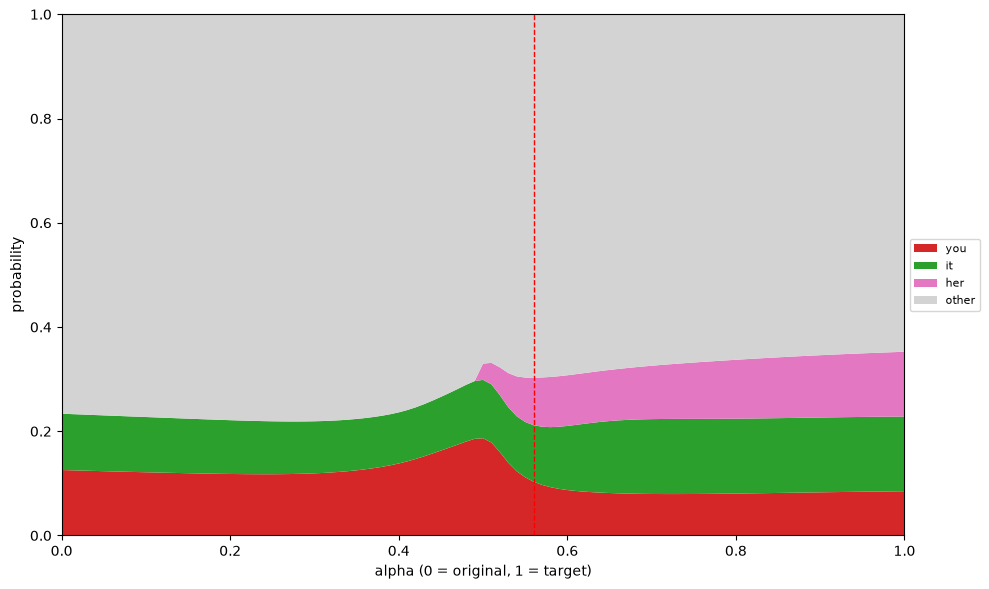

({0: torch.return_types.topk(
  values=tensor([0.1256, 0.1080, 0.0668, 0.0470, 0.0411]),
  indices=tensor([345, 340, 326, 428, 526])),
  1: torch.return_types.topk(
  values=tensor([0.1252, 0.1079, 0.0667, 0.0470, 0.0414]),
  indices=tensor([345, 340, 326, 428, 526])),
  2: torch.return_types.topk(
  values=tensor([0.1247, 0.1077, 0.0666, 0.0470, 0.0418]),
  indices=tensor([345, 340, 326, 428, 526])),
  3: torch.return_types.topk(
  values=tensor([0.1243, 0.1075, 0.0664, 0.0470, 0.0421]),
  indices=tensor([345, 340, 326, 428, 526])),
  4: torch.return_types.topk(
  values=tensor([0.1238, 0.1073, 0.0663, 0.0470, 0.0425]),
  indices=tensor([345, 340, 326, 428, 526])),
  5: torch.return_types.topk(
  values=tensor([0.1234, 0.1071, 0.0662, 0.0470, 0.0429]),
  indices=tensor([345, 340, 326, 428, 526])),
  6: torch.return_types.topk(
  values=tensor([0.1230, 0.1069, 0.0660, 0.0471, 0.0433]),
  indices=tensor([345, 340, 326, 428, 526])),
  7: torch.return_types.topk(
  values=tensor([0.1226, 

In [76]:
drift_sentence_meaning("gpt2", "Let's eat, grandma because I'm not going to eat", "", changed_index=3)